In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [3]:
data_path = Path(
    "archive/Ecommerce Order Dataset/train"
)

print("Dataset folder:", data_path.resolve())
print("Folder exists:", data_path.exists())

Dataset folder: C:\Users\aksha\Downloads\archive\archive\Ecommerce Order Dataset\train
Folder exists: False


In [4]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\aksha\Downloads\archive
['.ipynb_checkpoints', 'Ecommerce Order Dataset', 'Untitled.ipynb', 'Untitled1.ipynb']


In [6]:
import os

print("Jupyter current folder:")
print(os.getcwd())

print("\nFiles and folders available:")
print(os.listdir())

Jupyter current folder:
C:\Users\aksha\Downloads\archive

Files and folders available:
['.ipynb_checkpoints', 'Ecommerce Order Dataset', 'Untitled.ipynb', 'Untitled1.ipynb']


In [7]:
from pathlib import Path

current_folder = Path.cwd()

order_files = list(
    current_folder.rglob("df_Orders.csv")
)

print("Files found:")

for file in order_files:
    print(file)

Files found:
C:\Users\aksha\Downloads\archive\Ecommerce Order Dataset\test\df_Orders.csv
C:\Users\aksha\Downloads\archive\Ecommerce Order Dataset\train\df_Orders.csv


In [8]:
train_order_files = [
    file for file in order_files
    if "train" in [part.lower() for part in file.parts]
]

if not train_order_files:
    raise FileNotFoundError(
        "Training dataset was not found. "
        "Extract archive(2).zip into the Jupyter folder."
    )

orders_file = train_order_files[0]
data_path = orders_file.parent

print("Training dataset folder found:")
print(data_path)

Training dataset folder found:
C:\Users\aksha\Downloads\archive\Ecommerce Order Dataset\train


In [9]:
import pandas as pd

orders = pd.read_csv(
    data_path / "df_Orders.csv"
)

order_items = pd.read_csv(
    data_path / "df_OrderItems.csv"
)

customers = pd.read_csv(
    data_path / "df_Customers.csv"
)

products = pd.read_csv(
    data_path / "df_Products.csv"
)

payments = pd.read_csv(
    data_path / "df_Payments.csv"
)

print("All training datasets loaded successfully")

All training datasets loaded successfully


In [10]:
from pathlib import Path

data_path = Path(
    r"C:\Users\YourName\Downloads\archive\Ecommerce Order Dataset\train"
)

print("Folder exists:", data_path.exists())

Folder exists: False


In [11]:
print(list(data_path.glob("*.csv")))

[]


In [13]:
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)

Orders: (89316, 7)
Order Items: (89316, 5)
Customers: (89316, 4)
Products: (89316, 6)
Payments: (89316, 5)


In [14]:
display(orders.head())
display(order_items.head())
display(customers.head())
display(products.head())
display(payments.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18


,order_id,product_id,seller_id,price,shipping_charges
0,Axfy13Hk4PIk,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65
1,v6px92oS8cLG,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79
2,Ulpf9skrhjfm,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38
3,bwJVWupf2keN,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72
4,Dd0QnrMk9Cj5,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66


,customer_id,customer_zip_code_prefix,customer_city,customer_state
0,hCT0x9JiGXBQ,58125,varzea paulista,SP
1,PxA7fv9spyhx,3112,armacao dos buzios,RJ
2,g3nXeJkGI0Qw,4119,jandira,SP
3,EOEsCQ6QlpIg,18212,uberlandia,MG
4,mVz5LO2Vd6cL,88868,ilhabela,SP


,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,90K0C1fIyQUf,toys,491.0,19.0,12.0,16.0
1,qejhpMGGVcsl,watches_gifts,440.0,18.0,14.0,17.0
2,qUS5d2pEAyxJ,costruction_tools_garden,2200.0,16.0,16.0,16.0
3,639iGvMyv0De,toys,1450.0,68.0,3.0,48.0
4,1lycYGcsic2F,toys,300.0,17.0,4.0,12.0


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,Axfy13Hk4PIk,1,credit_card,1,259.14
1,v6px92oS8cLG,1,credit_card,8,382.39
2,Ulpf9skrhjfm,1,credit_card,4,249.25
3,bwJVWupf2keN,1,credit_card,2,27.79
4,Dd0QnrMk9Cj5,1,credit_card,1,76.15


In [15]:
print("Orders columns:")
print(orders.columns.tolist())

print("\nOrder items columns:")
print(order_items.columns.tolist())

print("\nCustomers columns:")
print(customers.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

print("\nPayments columns:")
print(payments.columns.tolist())

Orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_timestamp', 'order_estimated_delivery_date']

Order items columns:
['order_id', 'product_id', 'seller_id', 'price', 'shipping_charges']

Customers columns:
['customer_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Products columns:
['product_id', 'product_category_name', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Payments columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


In [16]:
def clean_column_names(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )

    return df


orders = clean_column_names(orders)
order_items = clean_column_names(order_items)
customers = clean_column_names(customers)
products = clean_column_names(products)
payments = clean_column_names(payments)

print("Column names standardized")

Column names standardized


In [17]:
def data_quality_report(df, dataset_name):
    report = pd.DataFrame({
        "dataset": dataset_name,
        "column": df.columns,
        "data_type": df.dtypes.astype(str).values,
        "missing_count": df.isnull().sum().values,
        "missing_percentage": (
            df.isnull().mean().values * 100
        ).round(2),
        "unique_values": df.nunique().values
    })

    return report

In [18]:
raw_quality_report = pd.concat([
    data_quality_report(orders, "Orders"),
    data_quality_report(order_items, "Order Items"),
    data_quality_report(customers, "Customers"),
    data_quality_report(products, "Products"),
    data_quality_report(payments, "Payments")
], ignore_index=True)

display(
    raw_quality_report.sort_values(
        "missing_percentage",
        ascending=False
    ).head(20)
)

,dataset,column,data_type,missing_count,missing_percentage,unique_values
5,Orders,order_delivered_timestamp,str,1889,2.11,71143
17,Products,product_category_name,str,308,0.34,70
21,Products,product_width_cm,float64,15,0.02,93
20,Products,product_height_cm,float64,15,0.02,101
19,Products,product_length_cm,float64,15,0.02,99
18,Products,product_weight_g,float64,15,0.02,2020
4,Orders,order_approved_at,str,9,0.01,68215
0,Orders,order_id,str,0,0.00,89316
15,Customers,customer_state,str,0,0.00,27
25,Payments,payment_installments,int64,0,0.00,24


In [19]:
print("Duplicate records:")

print("Orders:", orders.duplicated().sum())
print("Order Items:", order_items.duplicated().sum())
print("Customers:", customers.duplicated().sum())
print("Products:", products.duplicated().sum())
print("Payments:", payments.duplicated().sum())

Duplicate records:
Orders: 0
Order Items: 0
Customers: 0
Products: 61865
Payments: 0


In [20]:
orders = orders.drop_duplicates().copy()
order_items = order_items.drop_duplicates().copy()
customers = customers.drop_duplicates().copy()
products = products.drop_duplicates().copy()
payments = payments.drop_duplicates().copy()

print("Exact duplicates removed successfully")

Exact duplicates removed successfully


In [21]:
print("Missing values in Orders:")
display(orders.isnull().sum())

print("\nMissing values in Order Items:")
display(order_items.isnull().sum())

print("\nMissing values in Products:")
display(products.isnull().sum())

Missing values in Orders:


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   9
order_delivered_timestamp        1889
order_estimated_delivery_date       0
dtype: int64


Missing values in Order Items:


order_id            0
product_id          0
seller_id           0
price               0
shipping_charges    0
dtype: int64


Missing values in Products:


product_id                 0
product_category_name    141
product_weight_g           2
product_length_cm          2
product_height_cm          2
product_width_cm           2
dtype: int64

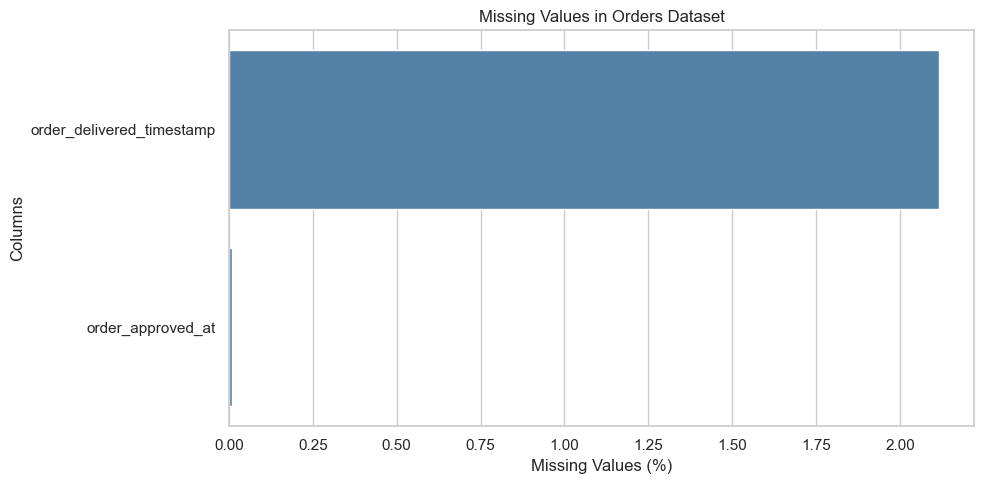

In [22]:
missing_percentage = (
    orders.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage = missing_percentage[
    missing_percentage > 0
]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index,
    color="steelblue"
)

plt.title("Missing Values in Orders Dataset")
plt.xlabel("Missing Values (%)")
plt.ylabel("Columns")
plt.tight_layout()
plt.show()

In [27]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_timestamp",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(
        orders[column],
        errors="coerce"
    )

print(orders[date_columns].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_timestamp        datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [28]:
order_items["price"] = pd.to_numeric(
    order_items["price"],
    errors="coerce"
)

order_items["shipping_charges"] = pd.to_numeric(
    order_items["shipping_charges"],
    errors="coerce"
)

numeric_product_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for column in numeric_product_columns:
    products[column] = pd.to_numeric(
        products[column],
        errors="coerce"
    )

print("Numeric columns converted successfully")

Numeric columns converted successfully


In [29]:
print(
    "Negative prices:",
    (order_items["price"] < 0).sum()
)

print(
    "Negative shipping charges:",
    (order_items["shipping_charges"] < 0).sum()
)

Negative prices: 0
Negative shipping charges: 0


In [30]:
order_items.loc[
    order_items["price"] < 0,
    "price"
] = np.nan

order_items.loc[
    order_items["shipping_charges"] < 0,
    "shipping_charges"
] = np.nan

In [31]:
order_items["price"] = order_items["price"].fillna(
    order_items["price"].median()
)

order_items["shipping_charges"] = (
    order_items["shipping_charges"].fillna(
        order_items["shipping_charges"].median()
    )
)

In [32]:
for column in numeric_product_columns:
    products[column] = products[column].fillna(
        products[column].median()
    )

In [33]:
products["product_category_name"] = (
    products["product_category_name"]
    .fillna("unknown")
)

In [34]:
delivery_orders = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_purchase_timestamp"].notna()) &
    (orders["order_delivered_timestamp"].notna()) &
    (orders["order_estimated_delivery_date"].notna())
].copy()

print(
    "Valid delivered orders:",
    delivery_orders.shape[0]
)

Valid delivered orders: 87422


In [35]:
delivery_orders["delivery_time_days"] = (
    delivery_orders["order_delivered_timestamp"] -
    delivery_orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

display(
    delivery_orders[
        [
            "order_id",
            "order_purchase_timestamp",
            "order_delivered_timestamp",
            "delivery_time_days"
        ]
    ].head()
)

,order_id,order_purchase_timestamp,order_delivered_timestamp,delivery_time_days
0,Axfy13Hk4PIk,2017-10-22 18:57:54,2017-10-26 22:19:52,4.140255
1,v6px92oS8cLG,2018-06-20 21:40:31,2018-07-03 22:51:22,13.049201
2,Ulpf9skrhjfm,2018-02-16 16:19:31,2018-02-27 01:29:50,10.382164
3,bwJVWupf2keN,2018-08-18 18:04:29,2018-08-27 20:03:51,9.082894
4,Dd0QnrMk9Cj5,2017-12-22 16:44:04,2018-01-05 19:22:49,14.110243


In [36]:
negative_delivery_times = (
    delivery_orders["delivery_time_days"] < 0
).sum()

print(
    "Negative delivery times:",
    negative_delivery_times
)

Negative delivery times: 0


In [38]:
delivery_orders = delivery_orders[
    delivery_orders["delivery_time_days"] >= 0
].copy()

In [39]:
delivery_orders["delay_days"] = (
    delivery_orders["order_delivered_timestamp"] -
    delivery_orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

delivery_orders["is_late"] = (
    delivery_orders["delay_days"] > 0
)

delivery_orders["delivery_status"] = np.where(
    delivery_orders["is_late"],
    "Late",
    "On Time"
)

display(
    delivery_orders[
        [
            "order_id",
            "delivery_time_days",
            "delay_days",
            "delivery_status"
        ]
    ].head()
)

,order_id,delivery_time_days,delay_days,delivery_status
0,Axfy13Hk4PIk,4.140255,-13.069537,On Time
1,v6px92oS8cLG,13.049201,-20.047662,On Time
2,Ulpf9skrhjfm,10.382164,-8.937616,On Time
3,bwJVWupf2keN,9.082894,-22.163993,On Time
4,Dd0QnrMk9Cj5,14.110243,-12.192488,On Time


In [40]:
Q1 = order_items["shipping_charges"].quantile(0.25)
Q3 = order_items["shipping_charges"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower limit:", round(lower_limit, 2))
print("Upper limit:", round(upper_limit, 2))

Q1: 20.11
Q3: 57.19
IQR: 37.08
Lower limit: -35.51
Upper limit: 112.81


In [41]:
order_items["shipping_charge_outlier"] = ~(
    order_items["shipping_charges"]
    .between(lower_limit, upper_limit)
)

print(
    "Shipping-charge outliers:",
    order_items["shipping_charge_outlier"].sum()
)

Shipping-charge outliers: 4615


In [43]:
order_items["shipping_charges_capped"] = (
    order_items["shipping_charges"].clip(
        lower=lower_limit,
        upper=upper_limit
    )
)

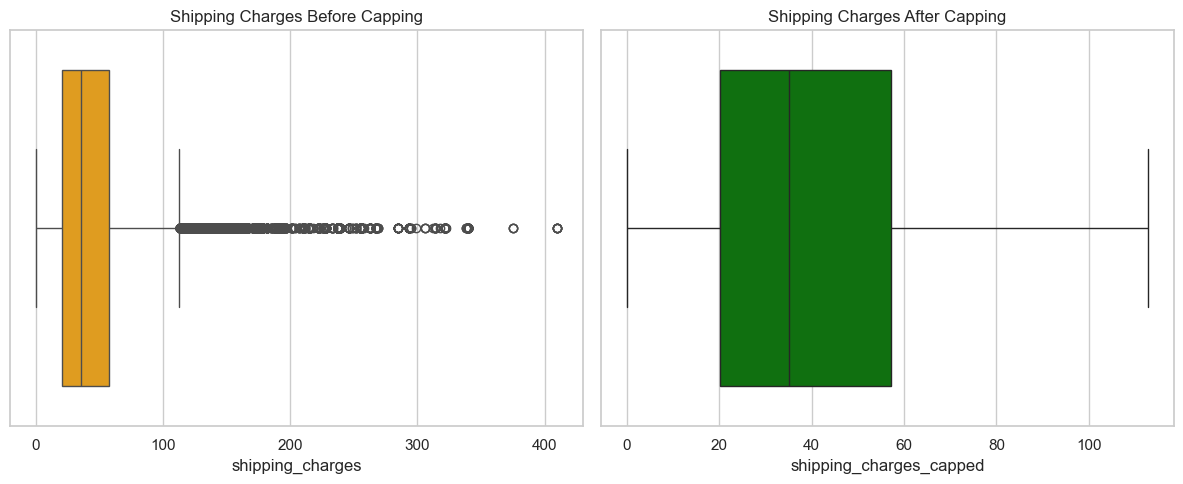

In [44]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

sns.boxplot(
    x=order_items["shipping_charges"],
    ax=axes[0],
    color="orange"
)

axes[0].set_title(
    "Shipping Charges Before Capping"
)

sns.boxplot(
    x=order_items["shipping_charges_capped"],
    ax=axes[1],
    color="green"
)

axes[1].set_title(
    "Shipping Charges After Capping"
)

plt.tight_layout()
plt.show()

In [45]:
item_summary = (
    order_items
    .groupby("order_id", as_index=False)
    .agg(
        total_item_value=("price", "sum"),
        total_shipping_charges=(
            "shipping_charges",
            "sum"
        ),
        capped_shipping_charges=(
            "shipping_charges_capped",
            "sum"
        ),
        item_count=("product_id", "count"),
        seller_count=("seller_id", "nunique")
    )
)

display(item_summary.head())

,order_id,total_item_value,total_shipping_charges,capped_shipping_charges,item_count,seller_count
0,001gkk6BwKEB,12.69,7.01,7.01,1,1
1,0029bAIZFMKA,692.00,163.52,112.81,1,1
2,002Jk8hp9Bhy,41.79,87.87,87.87,1,1
3,002ohHsWSKrP,459.00,21.91,21.91,1,1
4,0041NijdAYB0,518.18,32.11,32.11,1,1


In [46]:
logistics_data = delivery_orders.merge(
    item_summary,
    on="order_id",
    how="left",
    validate="one_to_one"
)

print("Shape after item merge:", logistics_data.shape)

Shape after item merge: (87422, 16)


In [47]:
customer_columns = [
    "customer_id",
    "customer_city",
    "customer_state"
]

logistics_data = logistics_data.merge(
    customers[customer_columns],
    on="customer_id",
    how="left",
    validate="many_to_one"
)

print(
    "Shape after customer merge:",
    logistics_data.shape
)

Shape after customer merge: (87422, 18)


In [48]:
logistics_data["freight_to_value_ratio"] = (
    logistics_data["total_shipping_charges"] /
    logistics_data["total_item_value"].replace(
        0,
        np.nan
    )
)

logistics_data["purchase_month"] = (
    logistics_data[
        "order_purchase_timestamp"
    ]
    .dt.to_period("M")
    .astype(str)
)

display(logistics_data.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,delivery_time_days,delay_days,is_late,delivery_status,total_item_value,total_shipping_charges,capped_shipping_charges,item_count,seller_count,customer_city,customer_state,freight_to_value_ratio,purchase_month
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,4.140255,-13.069537,False,On Time,223.51,84.65,84.65,1,1,varzea paulista,SP,0.378730,2017-10
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,13.049201,-20.047662,False,On Time,170.80,23.79,23.79,1,1,armacao dos buzios,RJ,0.139286,2018-06
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,10.382164,-8.937616,False,On Time,64.40,17.38,17.38,1,1,jandira,SP,0.269876,2018-02
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,9.082894,-22.163993,False,On Time,264.50,30.72,30.72,1,1,uberlandia,MG,0.116144,2018-08
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,14.110243,-12.192488,False,On Time,779.90,30.66,30.66,1,1,ilhabela,SP,0.039313,2017-12


In [49]:
average_delivery_time = (
    logistics_data["delivery_time_days"].mean()
)

median_delivery_time = (
    logistics_data["delivery_time_days"].median()
)

late_rate = (
    logistics_data["is_late"].mean() * 100
)

on_time_rate = 100 - late_rate

average_freight = (
    logistics_data[
        "total_shipping_charges"
    ].mean()
)

total_freight = (
    logistics_data[
        "total_shipping_charges"
    ].sum()
)

print(
    "Average Delivery Time:",
    round(average_delivery_time, 2),
    "days"
)

print(
    "Median Delivery Time:",
    round(median_delivery_time, 2),
    "days"
)

print(
    "On-Time Delivery Rate:",
    round(on_time_rate, 2),
    "%"
)

print(
    "Late Delivery Rate:",
    round(late_rate, 2),
    "%"
)

print(
    "Average Shipping Charge:",
    round(average_freight, 2)
)

print(
    "Total Shipping Charges:",
    round(total_freight, 2)
)

Average Delivery Time: 12.43 days
Median Delivery Time: 10.19 days
On-Time Delivery Rate: 92.29 %
Late Delivery Rate: 7.71 %
Average Shipping Charge: 44.24
Total Shipping Charges: 3867981.77


C:\Users\aksha\AppData\Local\Temp\ipykernel_18652\4226074918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


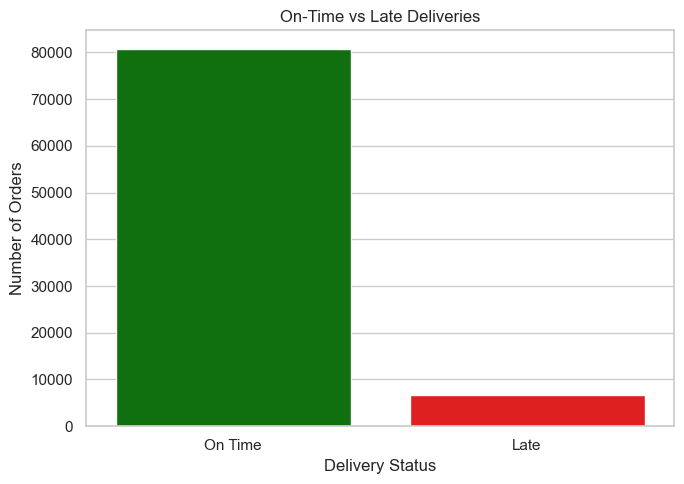

In [50]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=logistics_data,
    x="delivery_status",
    palette={
        "On Time": "green",
        "Late": "red"
    }
)

plt.title("On-Time vs Late Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

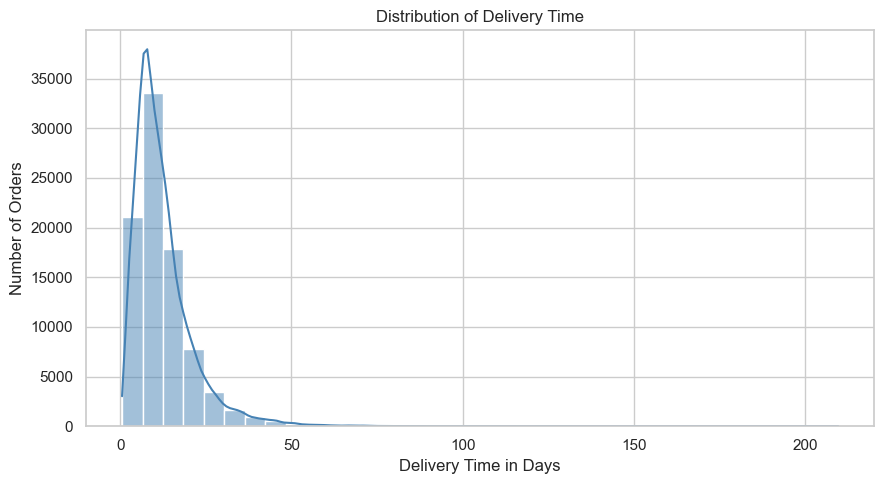

In [51]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=logistics_data,
    x="delivery_time_days",
    bins=35,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time in Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [52]:
columns_to_normalize = [
    "delivery_time_days",
    "capped_shipping_charges",
    "total_item_value"
]

model_data = logistics_data.dropna(
    subset=columns_to_normalize
).copy()

scaler = StandardScaler()

normalized_values = scaler.fit_transform(
    model_data[columns_to_normalize]
)

normalized_column_names = [
    "delivery_time_scaled",
    "shipping_charges_scaled",
    "item_value_scaled"
]

model_data[normalized_column_names] = (
    normalized_values
)

display(
    model_data[
        columns_to_normalize +
        normalized_column_names
    ].head()
)

,delivery_time_days,capped_shipping_charges,total_item_value,delivery_time_scaled,shipping_charges_scaled,item_value_scaled
0,4.140255,84.65,223.51,-0.894562,1.475607,-0.212176
1,13.049201,23.79,170.80,0.066326,-0.619491,-0.306343
2,10.382164,17.38,64.40,-0.221331,-0.840154,-0.496427
3,9.082894,30.72,264.50,-0.361466,-0.380927,-0.138947
4,14.110243,30.66,779.90,0.180767,-0.382992,0.781819


In [53]:
assert logistics_data["order_id"].notna().all()
assert logistics_data["order_id"].is_unique
assert logistics_data["delivery_time_days"].ge(0).all()
assert logistics_data["is_late"].isin([True, False]).all()
assert logistics_data["total_shipping_charges"].ge(0).all()

print("All final validation checks passed successfully")

All final validation checks passed successfully


In [54]:
output_folder = Path("data/processed")

output_folder.mkdir(
    parents=True,
    exist_ok=True
)

print("Output folder:", output_folder.resolve())

Output folder: C:\Users\aksha\Downloads\archive\data\processed


In [55]:
logistics_data.to_csv(
    output_folder / "logistics_clean.csv",
    index=False
)

model_data.to_csv(
    output_folder / "logistics_model_ready.csv",
    index=False
)

raw_quality_report.to_csv(
    output_folder / "raw_data_quality_report.csv",
    index=False
)

print("All processed files exported successfully")

All processed files exported successfully


In [56]:
for file in output_folder.glob("*.csv"):
    print(
        file.name,
        "-",
        round(file.stat().st_size / 1024, 2),
        "KB"
    )

logistics_clean.csv - 19008.37 KB
logistics_model_ready.csv - 24090.56 KB
raw_data_quality_report.csv - 1.2 KB
